Diferenças finitas linear para problemas de Neumann

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def p(x):
    return 1

def q(x):
    return -2

def r(x):
    return np.exp(x)*(np.cos(x) + np.sin(x))
def real_f(x):
    return np.exp(x)*np.sin(x)

In [3]:
def thomas_algorithm(a,b,d,B,ti,tf,h,alpha,beta):
    N = len(b)
    y = np.zeros(N)
    a[0] = a[0]/d[0]
    B[0] = B[0]/d[0]

    for i in range(1, N - 1):
        a[i]  = a[i] / (d[i] - b[i]*a[i - 1])
        B[i] = (B[i] - b[i]*B[i - 1]) / (d[i] - b[i]*a[i - 1])

    B[N - 1] = (B[N - 1] - b[N - 1]*B[N - 2]) / (d[N - 1] - b[N - 1]*a[N - 2])
    y[N - 1] = B[N - 1]

    for i in range(N - 2, -1, -1):
        y[i] = B[i] - a[i]*y[i + 1]

    return y

In [4]:
def diferencas_finitas_neumann(ti,tf,h,alpha,beta,p,q,r):
    N = int(np.round((tf - ti)/h))
    t = np.linspace(ti,tf,N + 1)
    n_sistema = (N + 1) - 1

    y = np.zeros(N + 1)
    a = np.zeros(n_sistema) #Diagonal principal
    b = np.zeros(n_sistema) #Diagonal superior
    d = np.zeros(n_sistema) #Resultados
    c = np.zeros(n_sistema) #Diagonal inferior

    a[0] = -1
    b[0] = 1
    d[0] = alpha*h

    for i in range(1, n_sistema - 1):
        a[i] = 2 + (h**2)*q(t[i])
        b[i] = -1 + (h/2)*p(t[i])
        c[i] = -1 - (h/2)*p(t[i])
        d[i] = -(h**2)*r(t[i])

    a[n_sistema - 1] = 2 + (h**2)*q(t[N - 1])
    c[n_sistema - 1] = -1 -(h / 2)*p(t[N - 1])
    d[n_sistema - 1] = -(h**2)*r(t[N - 1]) + (1 - (h/2)*p(t[N - 1]))*beta

    #Algorítmo de Thomas
    y[-1] = beta
    y[:-1] = thomas_algorithm(b,c,a,d,ti,tf,h,alpha,beta)

    return t,y

In [5]:
t,y = diferencas_finitas_neumann(0,np.pi/2,np.pi/20,1,np.exp(np.pi/2),p,q,r)
t_real= np.linspace(0,np.pi/2)
y_real = real_f(t_real)


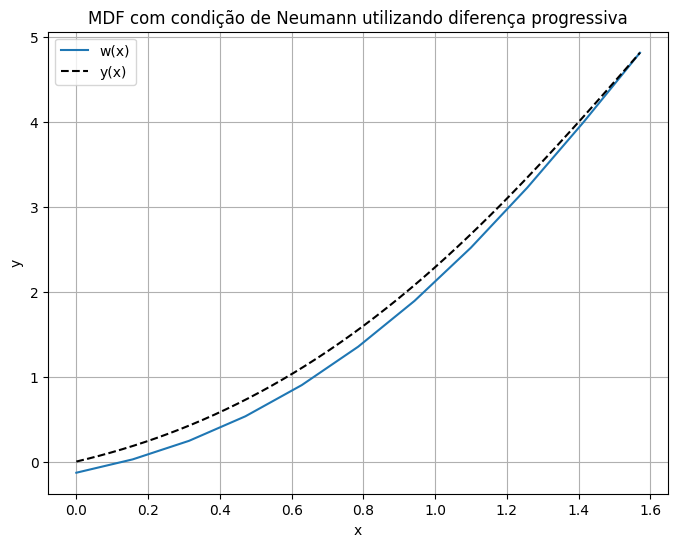

In [6]:
plt.figure(figsize = (8,6))
plt.plot(t,y, label = "w(x)")
plt.plot(t_real,y_real,label = "y(x)", linestyle = "--", color = "black")
plt.title("MDF com condição de Neumann utilizando diferença progressiva")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

Utilizando Ghost points:

In [7]:
def p(x):
    return 1

def q(x):
    return -2

def r(x):
    return np.exp(x)*(np.cos(x) + np.sin(x))
def real_f(x):
    return np.exp(x)*np.sin(x)

In [ ]:
def diferencas_finitas_ghost(ti,tf,h,alpha,beta,p,q,r):
    N = int(np.round((tf - ti)/h))
    t = np.linspace(ti,tf,N + 1)
    n_sistema = (N + 1) - 1

    y = np.zeros(N + 1)
    a = np.zeros(n_sistema) #Diagonal principal
    b = np.zeros(n_sistema) #Diagonal superior
    d = np.zeros(n_sistema) #Resultados
    c = np.zeros(n_sistema) #Diagonal inferior


    a[0] = -2 - h**2 * q(t[0])
    b[0] = 2
    d[0] = h**2 * p(t[0]) * alpha + h**2 * r(t[0]) + 2*h*alpha

    for i in range(1, n_sistema - 1):
        a[i] = 2 + (h**2)*q(t[i])
        b[i] = -1 + (h/2)*p(t[i])
        c[i] = -1 - (h/2)*p(t[i])
        d[i] = -(h**2)*r(t[i])

    a[n_sistema - 1] = 2 + (h**2)*q(t[N - 1])
    c[n_sistema - 1] = -1 -(h / 2)*p(t[N - 1])
    d[n_sistema - 1] = -(h**2)*r(t[N - 1]) + (1 - (h/2)*p(t[N - 1]))*beta

    #Algorítmo de Thomas
    y[-1] = beta
    y[:-1] = thomas_algorithm(b,c,a,d,ti,tf,h,alpha,beta)

    return t,y

In [9]:
t2,y2 = diferencas_finitas_ghost(0,np.pi/2,np.pi/20,1,np.exp(np.pi/2),p,q,r)

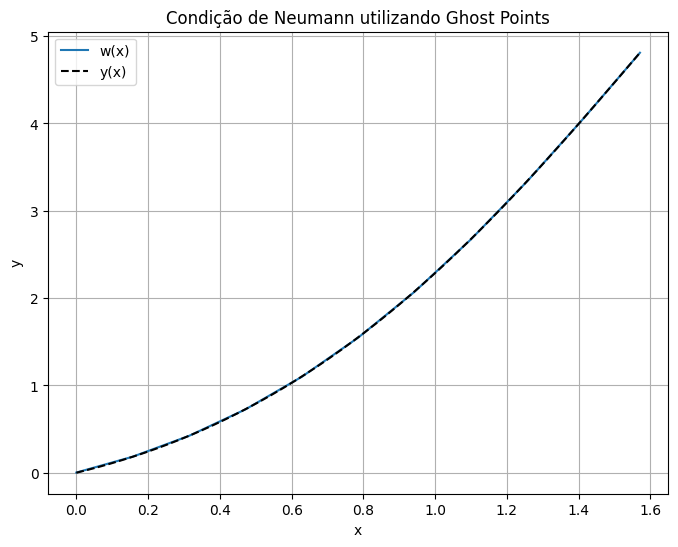

In [10]:
plt.figure(figsize = (8,6))
plt.plot(t2,y2, label = "w(x)")
plt.plot(t_real,y_real,label = "y(x)", linestyle = "--", color = "black")
plt.title("Condição de Neumann utilizando Ghost Points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()